# โค้ด 8.1 Convolutional Layer

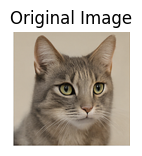

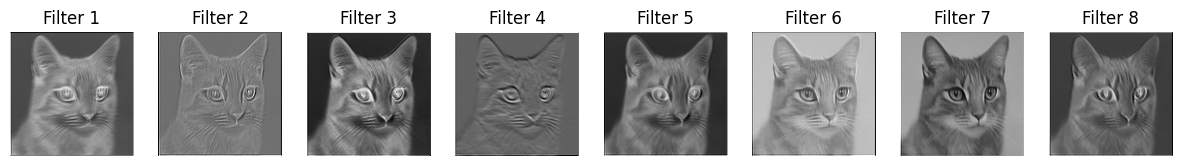

In [ ]:
#1️⃣ เตรียมไลบรารี
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
#2️⃣ โหลดและเตรียมภาพ
# โหลดภาพ (เปลี่ยน path ได้)
img_path ='/content/drive/MyDrive/aiforeveryone/cnn/cats/cat1.jpg'

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0)  # shape: [1, 3, 128, 128]
#3️⃣ สร้าง Convolution Layer อย่างเดียว
conv_layer = nn.Conv2d(
    in_channels=3,
    out_channels=8,   # จำนวน filter
    kernel_size=3,
    stride=1,
    padding=1
)
#ตรงนี้คือหัวใจ
#มี 8 filters
#จะได้ 8 feature maps
#4️⃣ ส่งภาพเข้า Convolution
with torch.no_grad():
    feature_maps = conv_layer(input_tensor)
#Shape จะเป็น:
[1, 8, 128, 128]
#5️⃣ แสดงภาพต้นฉบับ
plt.figure(figsize=(1.5,1.5))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()
6#️⃣️⃣ แสดง Feature Map ของแต่ละ Filter
num_filters = feature_maps.shape[1]

plt.figure(figsize=(15, 5))
for i in range(num_filters):
    plt.subplot(1, num_filters, i+1)
    plt.imshow(feature_maps[0, i].cpu(), cmap="gray")
    plt.title(f"Filter {i+1}")
    plt.axis("off")

plt.show()

#โค้ด 8.2 CNN ด้วย LeNet โมเดลจำแนกภาพตัวเลขใช้ชุดข้อมูลจาก MNIST
## ขั้นตอนโดยรวม
* เตรียมข้อมูล MNIST (รูป 28×28 ขาว–ดำ)
* ปรับขนาดภาพให้เข้ากับ LeNet (28×28×1) ภาพขาว–ดำ ขนาด 28 พิกเซล × 28 พิกเซล
* สร้างโมเดล LeNet-5
* เทรนโมเดล
* ประเมินผล
* ทำนาย

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8154 - loss: 0.6338 - val_accuracy: 0.9612 - val_loss: 0.1400
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9556 - loss: 0.1447 - val_accuracy: 0.9770 - val_loss: 0.0821
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9743 - loss: 0.0860 - val_accuracy: 0.9802 - val_loss: 0.0690
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9827 - loss: 0.0595 - val_accuracy: 0.9843 - val_loss: 0.0535
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9863 - loss: 0.0463 - val_accuracy: 0.9867 - val_loss: 0.0476
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9885 - loss: 0.0369 - val_accuracy: 0.9837 - val_loss: 0.0516
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9907 - loss: 0.0308 - val_accuracy: 0.9865 - val_loss: 0.0480
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9923 - loss: 0.0252 - val_accuracy: 0

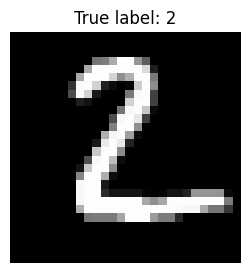

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step
Predicted: 2
Confidence: 0.9999947547912598


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense
import matplotlib.pyplot as plt # Added import for matplotlib

# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test_raw) = mnist.load_data() # y_test_raw is the original non-one-hot encoded labels

# 2. Normalize + reshape
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# 3. One-hot encoding labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test_raw, 10) # Use y_test_raw for one-hot encoding

# 4. Build LeNet-5 model
model = Sequential([
    Conv2D(filters=6, kernel_size=(5,5), activation='tanh', padding='same', input_shape=(28,28,1)),
    AveragePooling2D(pool_size=(2,2)),

    Conv2D(filters=16, kernel_size=(5,5), activation='tanh'),
    AveragePooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

# 5. Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 6. Train model
history = model.fit(x_train, y_train,
                    validation_split=0.1,
                    batch_size=128,
                    epochs=15,
                    verbose=1)

# 7. Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# 8. Predict example ภาพ x_test[0]
import numpy as np # Ensure numpy is imported for argmax
#idx =0 ตือเลข 7
idx = 0 # Define idx for the example
plt.figure(figsize=(3,3))
plt.imshow(x_test[idx].squeeze(), cmap="gray")
plt.title(f"True label: {y_test_raw[idx]}") # Corrected to use y_test_raw
plt.axis("off")
plt.show()

sample = x_test[0].reshape(1,28,28,1)
prediction = model.predict(sample)
print("Predicted:", np.argmax(prediction))
print("Confidence:", float(np.max(prediction)))

# Mount to file image - Number 8

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/aiforeveryone

Mounted at /content/drive
accident.mp4		      coins_result.png	 source.jpg
aiforeveryone_lession8.ipynb  coint.png		 style_103.png
aiforeveryone_lesson10.ipynb  content_103.png	 styled_output.png
aiforeveryone_Lesson4.ipynb   content_style.png  style_style.png
aiforeveryone_lesson5.ipynb   emails_spam.csv	 target
aiforeveryone_lesson6.ipynb   fabric		 test.png
aiforeveryone_lesson7.ipynb   feature		 thaistyle
aiforeveryone_lesson9.ipynb   leaf.png		 traffic_detect.mp4
aiforeveryron_lesson3.ipynb   model.jpg		 traffic_mask.png
aiforeveyone_Lesson1.ipynb    mri_scan.jpg	 traffic.mp4
aiforeveyone_Lesson2.ipynb    number8n.png	 traffic.png
ball.jpg		      number8.png	 traffics.png
ceramic_design.png	      riceb.jpg		 woman.mp4
ceramic.png		      rice.jpg		 ืีnumber8n.png
cnn			      sketch


In [ ]:
from PIL import Image
import numpy as np # Ensure numpy is imported for argmax if not already
import os # Import os module for path checks

# ---- 9. Load external image and predict ----
image_path = "/content/drive/MyDrive/aiforeveryone/number8.png"

# Check if the file exists before trying to open it
if os.path.exists(image_path):
    img = Image.open(image_path).convert("L")
    img = img.resize((28, 28))                 # resize to MNIST size
    img_arr = np.array(img).astype("float32")  # convert to array
    img_arr = img_arr / 255.0                  # normalize
    img_arr = img_arr.reshape(1, 28, 28, 1)    # reshape to model input

    prediction = model.predict(img_arr)
    print("Predicted class:", np.argmax(prediction))
    print("Confidence:", float(np.max(prediction)))
else:
    print(f"Error: The file '{image_path}' was not found.")
    print("Please ensure the file exists at this path and Google Drive is correctly mounted.")
    print("You can also run the previous cell with `!ls /content/drive/MyDrive/aiforeveryone` to verify the exact filename.")
    # Optionally, re-list the files for immediate verification:
    # !ls /content/drive/MyDrive/aiforeveryone

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted class: 5
Confidence: 0.9724226593971252


# โค้ด 8.3 CNN กับ YOLO เพื่อตรวจจับวัตถุ

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np # Add numpy import
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab
import cv2 # Ensure cv2 is imported

# ------------------------------------------
# 1) ฟังก์ชัน Block ของ CNN
# ------------------------------------------
def conv_block(x, filters, k=3):
    x = layers.Conv2D(filters, k, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=2)(x)
    return x


# ------------------------------------------
# 2) YOLO Model (tiny version)
# ------------------------------------------
def tiny_yolo(input_shape=(224, 224, 3), S=7, B=2, C=3):
    """
    input_shape = ขนาดภาพ
    S = grid size
    B = จำนวน bounding boxes ต่อกริด
    C = จำนวนคลาส
    """
    inputs = layers.Input(input_shape)

    # Feature Extractor (CNN)
    x = conv_block(inputs, 16)
    x = conv_block(x, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)
    x = conv_block(x, 512)

    # Flatten → Fully Connected
    x = layers.Flatten()(x)
    x = layers.Dense(4096, activation='relu')(x)

    # Output YOLO
    output_dim = S * S * (B * 5 + C)   # (x,y,w,h,conf)*B + C
    outputs = layers.Dense(output_dim, activation='linear')(x)

    outputs = layers.Reshape((S, S, B * 5 + C))(outputs)

    model = models.Model(inputs, outputs)
    return model


# ------------------------------------------
# 3) สร้างโมเดลและดูโครงสร้าง
# ------------------------------------------
keras_yolo_model = tiny_yolo() # Renamed variable to avoid conflict with PyTorch model
keras_yolo_model.summary()
print("Keras Tiny YOLO Model is loaded.")



# ---------------------------------------------------
# 4) Extract YOLO Boxes
# ---------------------------------------------------
def extract_boxes(y_pred, S=7, B=2, C=3, threshold=0.5):
    boxes = []
    cell_size = 1.0 / S

    for i in range(S):
        for j in range(S):
            cell = y_pred[i, j]

            for b in range(B):
                offset = b * 5
                px, py, w, h, conf = cell[offset:offset+5]

                if conf > threshold:
                    cx = (j + px) * cell_size
                    cy = (i + py) * cell_size
                    boxes.append([cx, cy, w, h, conf])

    return boxes


# ---------------------------------------------------
# 5) ฟังก์ชัน Detect จากไฟล์ภาพ
# ---------------------------------------------------
def detect_image(image_path, S=7, B=2, C=3):
    image = cv2.imread(image_path)
    if image is None:
        print("Cannot load image.")
        return

    orig = image.copy()
    h, w, _ = orig.shape

    # Preprocess
    resized = cv2.resize(image, (224, 224))
    inp = resized / 255.0
    inp = np.expand_dims(inp, axis=0)

    # Predict using the Keras model
    pred = keras_yolo_model.predict(inp, verbose=0)[0] # Use keras_yolo_model

    # Extract boxes
    boxes = extract_boxes(pred, S, B, C, threshold=0.5)

    # Draw boxes
    for (cx, cy, bw, bh, conf) in boxes:
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)

        cv2.rectangle(orig, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(orig, f"car {conf:.2f}", (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    cv2_imshow(orig) # Changed cv2.imshow to cv2_imshow
    cv2.waitKey(0)
    cv2.destroyAllWindows()


# ---------------------------------------------------
# 6) ตัวอย่างเรียกใช้งาน
# ---------------------------------------------------
detect_image("/content/drive/MyDrive/aiforeveryone/traffic.png")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    18,878,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 637)            │     2,609,78

 Total params: 23,065,053 (87.99 MB)

 Trainable params: 23,063,037 (87.98 MB)

 Non-trainable params: 2,016 (7.88 KB)

Keras Tiny YOLO Model is loaded.
Cannot load image.


# YOLO5

ติดตั้ง YOLO5

## ติดตั้งแพ็กเกจ ติดตั้งแล้วควร Restart session ใหม่เสมอ

In [ ]:
!pip install -U ultralytics

# Mount ไฟล์

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive/aiforeveryone

Mounted at /content/drive
accident.mp4		      coins_result.png	 style_103.png
aiforeveryone_lession8.ipynb  coint.png		 styled_output.png
aiforeveryone_lesson10.ipynb  content_103.png	 style_style.png
aiforeveryone_Lesson4.ipynb   content_style.png  target
aiforeveryone_lesson5.ipynb   emails_spam.csv	 test.png
aiforeveryone_lesson6.ipynb   fabric		 thaistyle
aiforeveryone_lesson7.ipynb   feature		 traffic_detect.mp4
aiforeveryone_lesson9.ipynb   leaf.png		 traffic_mask.png
aiforeveryron_lesson3.ipynb   mri_scan.jpg	 traffic.mp4
aiforeveyone_Lesson1.ipynb    number8n.png	 traffic.png
aiforeveyone_Lesson2.ipynb    number8.png	 traffics.png
ball.jpg		      riceb.jpg		 woman.mp4
ceramic_design.png	      rice.jpg		 ืีnumber8n.png
ceramic.png		      sketch
cnn			      source.jpg


# Load Model YOLOv5

In [ ]:
#Test if GPU loaded
#Runtime/Change runtime type เลือก GPU นะคะ
#หลังจากนั้น Restart session ก่อนค่อยทดสอบว่าเจอ GPU ไหม
!nvidia-smi

Mon Dec 22 12:38:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P0             28W /   70W |     218MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
model = torch.hub.load(
    'ultralytics/yolov5',
    'yolov5s',
    pretrained=True
)

model.to('cuda')  # ถ้ามี GPU


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2025-12-22 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


AutoShape(
  (model): DetectMultiBackend(
    (model): DetectionModel(
      (model): Sequential(
        (0): Conv(
          (conv): Conv2d(3, 32, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2))
          (act): SiLU(inplace=True)
        )
        (1): Conv(
          (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (act): SiLU(inplace=True)
        )
        (2): C3(
          (cv1): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv3): Conv(
            (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            (act): SiLU(inplace=True)
          )
          (m): Sequential(
            (0): Bottleneck(
              (cv1): Conv(
                (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
  

# รันโมเดลเพื่อ detect จากวีดีโอ
##!! รันนานมาก เกือบสิบนาที !!

In [ ]:
import cv2

video_path = "/content/drive/MyDrive/aiforeveryone/traffic.mp4"     # ถ้าชื่อไฟล์ต่างให้แก้ตรงนี้
cap = cv2.VideoCapture(video_path)

# อ่านข้อมูลวิดีโอเดิม
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

# เตรียมบันทึกเป็นวิดีโอใหม่
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("/content/drive/MyDrive/aiforeveryone/traffic_detect.mp4", fourcc, fps, (w, h))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # ส่งเข้า YOLOv5
    results = model(frame)

    # YOLO วาดกรอบให้เรียบร้อย
    annotated = results.render()[0]

    # เขียนลงไฟล์ผลลัพธ์
    out.write(annotated)

cap.release()
out.release()
print("✔️ เสร็จแล้ว: /content/drive/MyDrive/aiforeveryone/traffic_detect.mp4")


# Download video ผลลัพธ์

## ในผลลัพธ์ YOLOv5 ตรวจจับคนด้วยแต่ไม่ถกต้อง ควรเขียนโปรแกรมใช้ Aspect ratio หาสัดส่วน Bounding-box ที่คาดว่าจะเป็นคนออกไป หรือปรับ Threshold



In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/aiforeveryone/traffic_detect.mp4")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Detect จากภาพ

In [ ]:
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab
import cv2 # Ensure cv2 is imported

def detect_image_yolov5(image_path):
    # อ่านภาพ
    img = cv2.imread(image_path)
    if img is None:
        print("Cannot load image:", image_path)
        return

    # รัน YOLOv5
    # YOLOv5 PyTorch model usually handles resizing internally for numpy arrays.
    # However, to be explicit and align with common YOLOv5 input sizes (e.g., 640x640),
    # we can resize it here. Let's use the default input size if not specified by the model.
    # The 'model' variable here refers to the PyTorch YOLOv5 model loaded previously.

    # YOLOv5's 'model()' call usually handles resizing if the input is a numpy array.
    # If not, you might need to resize explicitly.
    # For this error, the core issue is `model` pointing to Keras model.
    # Assuming 'model' is now the PyTorch YOLOv5 model:

    # It's good practice to resize the image to the expected input size for YOLOv5.
    # YOLOv5s typically expects 640x640.
    img_resized = cv2.resize(img, (640, 640)) # Resize for YOLOv5 model
    results = model(img_resized) # Pass the resized image to the PyTorch YOLOv5 model

    # แปลงผลลัพธ์เป็น bounding boxes
    df = results.pandas().xyxy[0]  # DataFrame: xmin, ymin, xmax, ymax, conf, class, name

    # วาดกล่องเฉพาะวัตถุที่เป็น "car", "truck", "bus"
    target_classes = ["car", "truck", "bus"]

    # Need to scale coordinates back to original image size if we resized for inference
    # But for display, we draw on the original image 'img', so scale the coordinates
    original_h, original_w, _ = img.shape
    resized_h, resized_w, _ = img_resized.shape

    x_scale = original_w / resized_w
    y_scale = original_h / resized_h

    for _, row in df.iterrows():
        label = row['name']
        if label not in target_classes:
            continue

        xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
        conf = row['confidence']

        # Scale bounding box coordinates back to original image size
        xmin = int(xmin * x_scale)
        ymin = int(ymin * y_scale)
        xmax = int(xmax * x_scale)
        ymax = int(ymax * y_scale)

        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0,255,0), 2)
        cv2.putText(img, f"{label} {conf:.2f}", (xmin, ymin - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    # แสดงภาพผลลัพธ์
    cv2_imshow(img)
detect_image_yolov5("/content/drive/MyDrive/aiforeveryone/traffic.png")

Output hidden; open in https://colab.research.google.com to view.

# โค้ด 8.4 Segmentation ใช้โมเดล ResNet101 ใน PyTorch

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


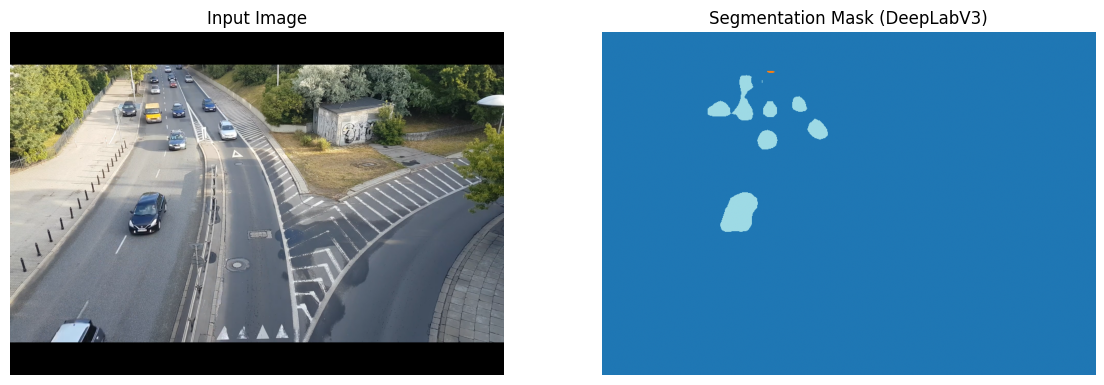

In [ ]:
import torch
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# โหลดภาพ
img_path = "/content/drive/MyDrive/aiforeveryone/traffic.png"
img = Image.open(img_path).convert("RGB")

# โมเดล Deeplabv3 แบบ pretrained
model = torch.hub.load('pytorch/vision:v0.10.0', 'deeplabv3_resnet101', pretrained=True)
model.eval()

# แปลงภาพ
transform = T.Compose([
    T.Resize(520),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

input_tensor = transform(img).unsqueeze(0)

# ทำนาย
with torch.no_grad():
    output = model(input_tensor)['out'][0]

# แปลง mask
mask = output.argmax(0).byte().cpu().numpy()

# ====== save mask ======
mask_img = Image.fromarray(mask)
mask_img.save('/content/drive/MyDrive/aiforeveryone/traffic_mask.png')


# แสดงผล
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.title("Input Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Segmentation Mask (DeepLabV3)")
plt.imshow(mask, cmap="tab20")
plt.axis("off")

plt.show()

## ถ้ารันแล้วไม่เห็นพบลัพธ์ ภาพ Mask ไม่แสดง
## Colab เตือนว่าพบข้อมูลในแคช ให้ลบข้อมูลออกใหม่ restart session ใหม่แล้วรันเซล (บน)ใหม่ จะเห็นภาพผลลัพธ์

In [ ]:
rm -rf /root/.cache/torch/hub

In [ ]:
import os
# ตรวจสอบว่ามีภาพไหม
img_path = "/content/drive/MyDrive/aiforeveryone/traffic_mask.png"
print(os.path.exists(img_path))


True


#​ Segmentation ด้วย U-Net

#ติดตั้ง

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# สร้าง U-Net เวอร์ชันมาตรฐาน (PyTorch)
*	in_channels = จำนวน channel ของภาพอินพุต (เช่น 3 สำหรับ RGB)
*	n_classes   = จำนวนคลาสของ mask (เช่น 1 สำหรับ binary, หรือหลายคลาส

In [ ]:
class DoubleConv(nn.Module):
    """Conv2D 2 ชั้น + BatchNorm + ReLU"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.double_conv(x)


class Down(nn.Module):
    """Downsampling: MaxPool + DoubleConv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)


class Up(nn.Module):
    """Upsampling: (bilinear หรือ ConvTranspose) + concat + DoubleConv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # in_channels = ช่องจาก skip-concat (encoder + upsample)
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2,
                                         kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # x1 = feature จาก decoder, x2 = feature จาก encoder (skip connection)
        x1 = self.up(x1)

        # เผื่อ H,W ไม่ตรงกัน (ตอนหาร 2 ติดเศษ)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])

        # concat ช่องตาม dim=1
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class OutConv(nn.Module):
    """เลเยอร์สุดท้าย 1x1 Conv → logits ของแต่ละคลาส"""
    def __init__(self, in_channels, n_classes):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, n_classes, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, n_classes=1, bilinear=True):
        super().__init__()
        self.in_channels = in_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc   = DoubleConv(in_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)

        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)        # 64
        x2 = self.down1(x1)     # 128
        x3 = self.down2(x2)     # 256
        x4 = self.down3(x3)     # 512
        x5 = self.down4(x4)     # bottleneck

        x = self.up1(x5, x4)
        x = self.up2(x,  x3)
        x = self.up3(x,  x2)
        x = self.up4(x,  x1)
        logits = self.outc(x)
        return logits

อ่านภาพ

In [ ]:
import torch

# สร้างโมเดล U-Net สำหรับ binary segmentation (1 class + background)
# แยกวัตถุ ออกจากพื้นหลัง
model = UNet(in_channels=3, n_classes=1)  # ถ้ามีหลายคลาส เปลี่ยน n_classes ได้

# dummy input: batch = 1, RGB = 3, H=W=512
x = torch.randn(1, 3, 512, 512)

with torch.no_grad():
    logits = model(x)  # shape: (1, 1, 512, 512) สำหรับ binary

print("Logits shape:", logits.shape)

Logits shape: torch.Size([1, 1, 512, 512])


#U-Net ใช้ Pre-trained encoder

แสดงผลลัพธ์และ Mask

In [ ]:
!pip install -q segmentation-models-pytorch timm

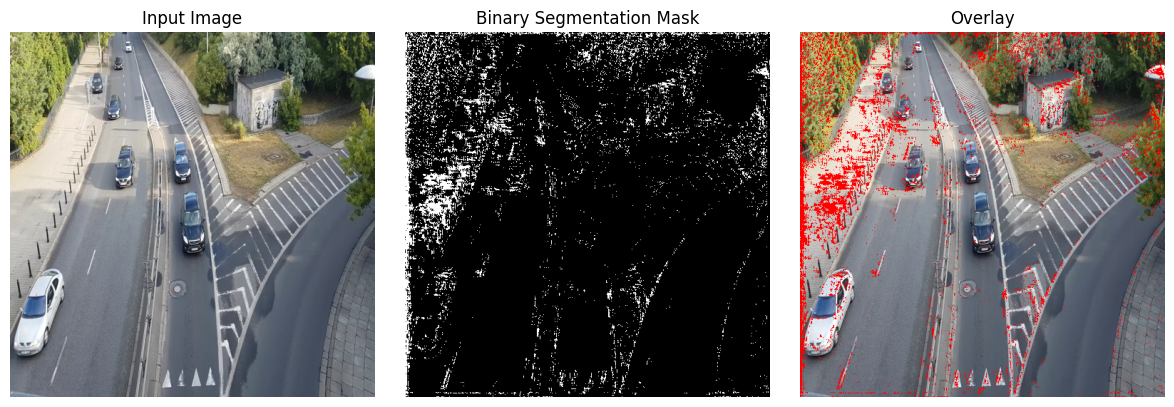

In [ ]:
# =========================
# U-Net Binary Segmentation (Pretrained)
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
import segmentation_models_pytorch as smp

# -------------------------
# 1) Config
# -------------------------
IMAGE_PATH = "/content/drive/MyDrive/aiforeveryone/traffics.png"
IMAGE_SIZE = 512
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# 2) Load Image
# -------------------------
img = Image.open(IMAGE_PATH).convert("RGB")

transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),   # [0,1]
    T.Normalize(    # ImageNet normalization (สำคัญมาก)
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = transform(img).unsqueeze(0).to(DEVICE)
img_np = np.array(img.resize((IMAGE_SIZE, IMAGE_SIZE)))

# -------------------------
# 3) Load Pretrained U-Net
# -------------------------
model = smp.Unet(
     encoder_name="resnet34",
    encoder_weights="imagenet",     # ✅ pretrained ImageNet
    in_channels=3,
    classes=1                       # ✅ binary segmentation
).to(DEVICE)

model.eval()   # inference mode

# -------------------------
# 4) Inference
# -------------------------
with torch.no_grad():
    logits = model(img_tensor)      # (1,1,H,W)
    prob   = torch.sigmoid(logits)  # 0–1
    mask   = (prob > 0.5).float()   # binary mask

mask_np = mask.squeeze().cpu().numpy()

# -------------------------
# 5) Visualization
# -------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(img_np)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Binary Segmentation Mask")
plt.imshow(mask_np, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
overlay = img_np.copy()
overlay[mask_np > 0] = [255, 0, 0]
plt.imshow(overlay)
plt.axis("off")

plt.tight_layout()
plt.show()

ดูความมั่นใจของโมเดลในการแบ่งส่วน

In [ ]:
print(prob.min().item(), prob.max().item())

0.279956579208374 0.6243273019790649


#โค้ด 8.6 Autoencoder MNIST เลข 4

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.4939 - val_loss: 0.2130
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2103 - val_loss: 0.1777
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1770 - val_loss: 0.1547
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1571 - val_loss: 0.1437
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1453 - val_loss: 0.1348
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1379 - val_loss: 0.1289
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1311 - val_loss: 0.1238
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1262 - val_loss: 0.1196
Epoch 9/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1216 - val_loss: 0.1166
Epoch 10/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1180 - val_loss: 0.1138
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


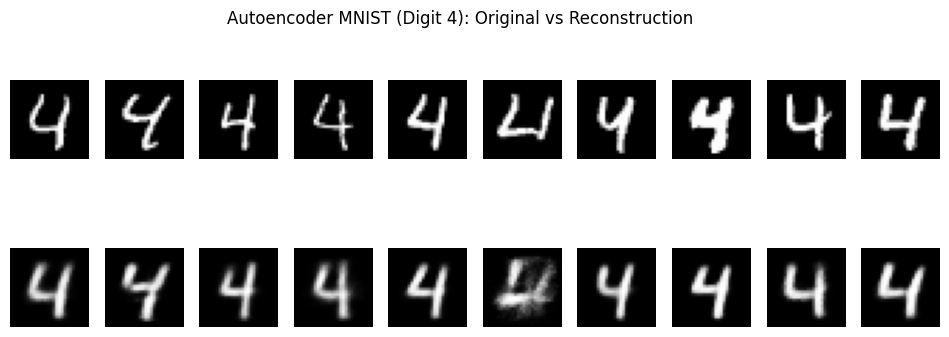

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape

# ---------------------------------------
# 1) โหลด MNIST และกรองเฉพาะเลข 4
# ---------------------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# เฉพาะเลข 4
x_train_4 = x_train[y_train == 4] / 255.0
x_test_4 = x_test[y_test == 4] / 255.0

# reshape
x_train_4 = x_train_4.reshape((-1, 28, 28, 1))
x_test_4 = x_test_4.reshape((-1, 28, 28, 1))

# ---------------------------------------
# 2) สร้าง Autoencoder
# ---------------------------------------

# Encoder
input_img = Input(shape=(28, 28, 1))
x = Flatten()(input_img)
encoded = Dense(32, activation='relu')(x)   # latent vector (ขนาด 32)

# Decoder
x = Dense(28*28, activation='sigmoid')(encoded)
decoded = Reshape((28, 28, 1))(x)

# โมเดล Autoencoder
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# ---------------------------------------
# 3) เทรน Autoencoder
# ---------------------------------------
autoencoder.fit(
    x_train_4, x_train_4,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

# ---------------------------------------
# 4) ทำนายและแสดงผล
# ---------------------------------------
decoded_imgs = autoencoder.predict(x_test_4[:10])

plt.figure(figsize=(12,4))
for i in range(10):
    # ภาพต้นฉบับ
    ax = plt.subplot(2, 10, i+1)
    plt.imshow(x_test_4[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # ภาพสร้างใหม่ (Reconstruction)
    ax = plt.subplot(2, 10, i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.suptitle("Autoencoder MNIST (Digit 4): Original vs Reconstruction")
plt.show()

#โค้ด  สกัดฟีเจอร์ใน CNN ทำ Motion

1) การแยกเฟรมจากวิดีโอ (Frame Extraction)
โค้ดนี้จะอ่านวิดีโอ แล้วดึงเฟรมออกมาเป็น NumPy array

In [ ]:
import cv2

def extract_frames(video_path, max_frames=60):
    cap = cv2.VideoCapture(video_path)
    frames = []
    count = 0

    while True:
        ret, frame = cap.read()
        if not ret or count >= max_frames:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
        count += 1

    cap.release()
    return frames

# ตัวอย่างการใช้งาน
video_path = "/content/drive/MyDrive/aiforeveryone/traffic.mp4"
frames = extract_frames(video_path)
print("จำนวนเฟรมที่ดึงได้:", len(frames))


จำนวนเฟรมที่ดึงได้: 60


2) ดึงฟีเจอร์จากแต่ละเฟรมด้วย CNN (Spatial Feature Extraction)
ใช้ PyTorch CNN แบบง่าย ๆ (Conv2D 2 ชั้น)

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as T
from PIL import Image
import numpy as np

# CNN extractor อย่างง่าย
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),  # -> (16, H/2, W/2)
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (32, H/4, W/4)
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))   # -> (32, 1, 1)  → feature vector 32 dim
        )

    def forward(self, x):
        x = self.features(x)
        return x.reshape(x.size(0), -1)   # flatten เป็น vector

cnn = SimpleCNN()


แปลงเฟรม Tensor เพื่อส่งเข้า CNN

In [ ]:
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((128, 128)),
    T.ToTensor()
])


ดึงฟีเจอร์ทีละเฟรม

In [ ]:
def extract_spatial_features(frames, cnn_model):
    feature_list = []

    for frame in frames:
        img_tensor = transform(frame).unsqueeze(0)  # (1,3,128,128)
        with torch.no_grad():
            feat = cnn_model(img_tensor)
        feature_list.append(feat.numpy()[0])  # เก็บ vector

    return np.array(feature_list)

frame_features = extract_spatial_features(frames, cnn)
print("รูปฟีเจอร์ของทุกเฟรม:", frame_features.shape)


รูปฟีเจอร์ของทุกเฟรม: (60, 32)


✅ 3) รวมฟีเจอร์เชิงเวลา (Temporal Feature Aggregation)
มีหลายแบบ เช่น:
1: ค่าเฉลี่ยของฟีเจอร์ทุกเฟรม (Temporal Average Pooling)
เหมาะสำหรับโมเดลง่าย

In [ ]:
video_feature = frame_features.mean(axis=0)
print("Temporal Feature Shape:", video_feature.shape)


Temporal Feature Shape: (32,)


In [ ]:
display(video_feature)

array([3.3066574e-02, 4.8966158e-02, 2.9142655e-03, 1.9086573e-03,
       1.3609378e-01, 6.7382783e-02, 1.4504777e-01, 1.9824658e-01,
       1.1007770e-01, 0.0000000e+00, 0.0000000e+00, 9.8151295e-04,
       1.5380451e-01, 4.2558033e-05, 3.1757586e-02, 1.1418433e-01,
       0.0000000e+00, 3.3257026e-02, 9.2671304e-05, 1.3613754e-02,
       2.3529647e-01, 1.1533937e-01, 1.4449479e-01, 0.0000000e+00,
       2.2764338e-02, 1.0717988e-01, 5.7795878e-02, 1.5355068e-01,
       2.6211946e-03, 1.2227298e-03, 3.9043196e-02, 2.3017938e-05],
      dtype=float32)

#โค้ด 8.7 VAE
##อาจเพิ่ม epoch ให้มากขึ้นจะได้ภาพที่ดีขึ้น

Epoch 1/400, Loss: 1804.72
Epoch 2/400, Loss: 1777.05
Epoch 3/400, Loss: 1754.20
Epoch 4/400, Loss: 1734.07
Epoch 5/400, Loss: 1712.57
Epoch 6/400, Loss: 1683.41
Epoch 7/400, Loss: 1676.79
Epoch 8/400, Loss: 1653.44
Epoch 9/400, Loss: 1642.55
Epoch 10/400, Loss: 1617.51
Epoch 11/400, Loss: 1619.52
Epoch 12/400, Loss: 1607.24
Epoch 13/400, Loss: 1610.47
Epoch 14/400, Loss: 1576.99
Epoch 15/400, Loss: 1553.92
Epoch 16/400, Loss: 1550.28
Epoch 17/400, Loss: 1521.41
Epoch 18/400, Loss: 1499.62
Epoch 19/400, Loss: 1459.96
Epoch 20/400, Loss: 1487.69
Epoch 21/400, Loss: 1385.08
Epoch 22/400, Loss: 1336.07
Epoch 23/400, Loss: 1303.76
Epoch 24/400, Loss: 1209.55
Epoch 25/400, Loss: 1229.50
Epoch 26/400, Loss: 1151.18
Epoch 27/400, Loss: 1112.38
Epoch 28/400, Loss: 1097.89
Epoch 29/400, Loss: 1069.56
Epoch 30/400, Loss: 986.12
Epoch 31/400, Loss: 996.04
Epoch 32/400, Loss: 991.77
Epoch 33/400, Loss: 967.69
Epoch 34/400, Loss: 905.13
Epoch 35/400, Loss: 942.23
Epoch 36/400, Loss: 865.29
Epoch 37

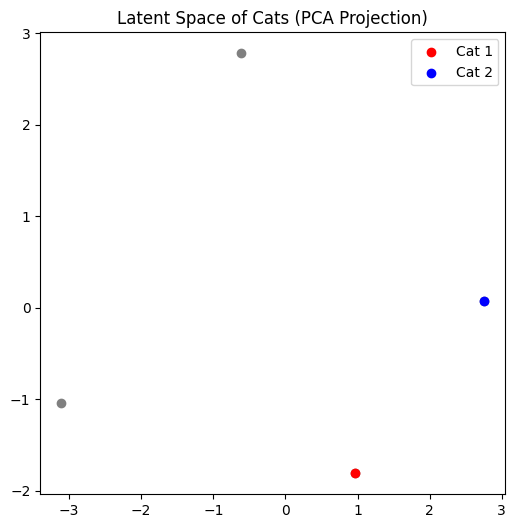

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from PIL import Image

# -------------------------------
# Custom Dataset for a single folder of images
# This bypasses the need for class subdirectories if all images are in one folder
# -------------------------------
class SingleFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        # Define supported image extensions
        extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.ppm', '*.pgm', '*.tif', '*.tiff', '*.webp']
        for ext in extensions:
            self.image_paths.extend(glob.glob(os.path.join(root_dir, ext)))
        # Filter out any non-image files or directories that might be caught by glob (e.g. .ipynb_checkpoints)
        self.image_paths = [p for p in self.image_paths if os.path.isfile(p)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # Return a dummy label for autoencoder, as it's not classification
        return image, 0

# -------------------------------
# 1) Dataset – โหลดภาพแมว
# -------------------------------

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Use the custom dataset instead of ImageFolder
dataset = SingleFolderDataset("/content/drive/MyDrive/aiforeveryone/cnn/cats", transform=transform)

# Check if the dataset is empty after filtering
if len(dataset) == 0:
    raise FileNotFoundError("No valid image files found in '/content/drive/MyDrive/aiforeveryone/cnn/cats'.\nPlease ensure your cat images (e.g., .jpg, .png) are directly within this folder.")

dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"


# -------------------------------
# 2) สร้าง VAE
# -------------------------------

class Encoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.ReLU(),
            nn.Flatten()
        )
        self.fc_mu = nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)

    def forward(self, x):
        h = self.conv(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128*8*8)
        self.decode = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, 8, 8)
        return self.decode(h)


class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def sample_z(self, mu, logvar):
        eps = torch.randn_like(mu)
        return mu + torch.exp(logvar/2) * eps

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.sample_z(mu, logvar)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar


# -------------------------------
# 3) Loss Function
# -------------------------------

def vae_loss(recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss


# -------------------------------
# 4) Train VAE
# -------------------------------

latent_dim = 16
model = VAE(latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 400
for epoch in range(epochs):
    for imgs, _ in dataloader:
        imgs = imgs.to(device)

        recon, mu, logvar = model(imgs)
        loss = vae_loss(recon, imgs, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.2f}")


# -------------------------------
# 5) ดึง Latent Space ของแมวตัวที่ 1 และ 2
# -------------------------------

# โหลดภาพ 2 ตัวอย่าง
load_transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor()
])

# Ensure there are at least two images in the dataset to sample
if len(dataset) < 2:
    print("Warning: Not enough images in the dataset to compare cat1 and cat2 latent spaces. Skipping this section.")
else:
    cat1 = load_transform(Image.open(dataset.image_paths[0]).convert('RGB'))
    cat2 = load_transform(Image.open(dataset.image_paths[1]).convert('RGB'))

    cat1 = cat1.unsqueeze(0).to(device)
    cat2 = cat2.unsqueeze(0).to(device)

    with torch.no_grad():
        mu1, logvar1 = model.encoder(cat1)
        mu2, logvar2 = model.encoder(cat2)

    mu1 = mu1.cpu().numpy()[0]
    mu2 = mu2.cpu().numpy()[0]

    print("Latent (cat1):", mu1)
    print("Latent (cat2):", mu2)

    # -------------------------------
    # 6) เปรียบเทียบระยะห่างใน Latent Space
    # -------------------------------

    dist = np.linalg.norm(mu1 - mu2)
    print(f"Distance between cat1 and cat2 latent vectors: {dist:.4f}")


    # -------------------------------
    # 7) แสดง latent space 2 มิติ (PCA)
    # -------------------------------

    from sklearn.decomposition import PCA

    latent_all = []

    for i in range(len(dataset)):
        img_tensor = load_transform(Image.open(dataset.image_paths[i]).convert('RGB')).unsqueeze(0).to(device)
        with torch.no_grad():
            mu, _ = model.encoder(img_tensor)
        latent_all.append(mu.cpu().numpy()[0])

    latent_all = np.array(latent_all)

    pca = PCA(n_components=2)
    latent_2d = pca.fit_transform(latent_all)

    plt.figure(figsize=(6,6))
    plt.scatter(latent_2d[:,0], latent_2d[:,1], color='gray')
    plt.scatter(latent_2d[0,0], latent_2d[0,1], color='red', label="Cat 1")
    plt.scatter(latent_2d[1,0], latent_2d[1,1], color='blue', label="Cat 2")
    plt.legend()
    plt.title("Latent Space of Cats (PCA Projection)")
    plt.show()

# สร้างภาพใหม่ด้วย VAE

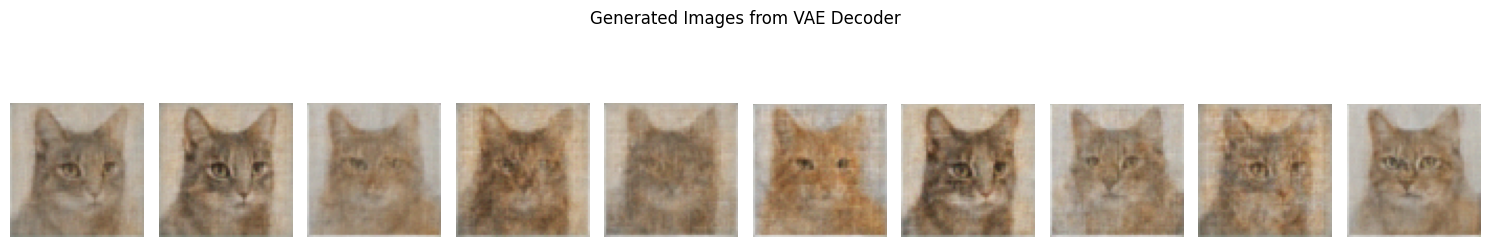

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Ensure the VAE model and device are available from previous execution
# If not, you might need to re-run the VAE training cell (j8PeGm0mB5tc).

# Set the model to evaluation mode
model.eval()

# Number of new images to generate
num_generated_images = 10

plt.figure(figsize=(15, 3))
plt.suptitle("Generated Images from VAE Decoder")

with torch.no_grad():
    for i in range(num_generated_images):
        # Sample a random latent vector
        # We can sample from a standard normal distribution (N(0,1)) or within the learned latent space bounds if known.
        # For simplicity, let's sample from N(0,1) for each dimension of the latent_dim.
        random_latent_vector = torch.randn(1, latent_dim).to(device)

        # Decode the latent vector to an image
        generated_img_tensor = model.decoder(random_latent_vector).squeeze(0).cpu()

        # Convert tensor to numpy array and transpose for plotting (C, H, W) -> (H, W, C)
        generated_img_np = np.transpose(generated_img_tensor.numpy(), (1, 2, 0))

        plt.subplot(1, num_generated_images, i + 1)
        plt.imshow(generated_img_np)
        plt.axis('off')

plt.tight_layout()
plt.show()

# แสดงภาพใน ปริภูมิของแมวสองตัว

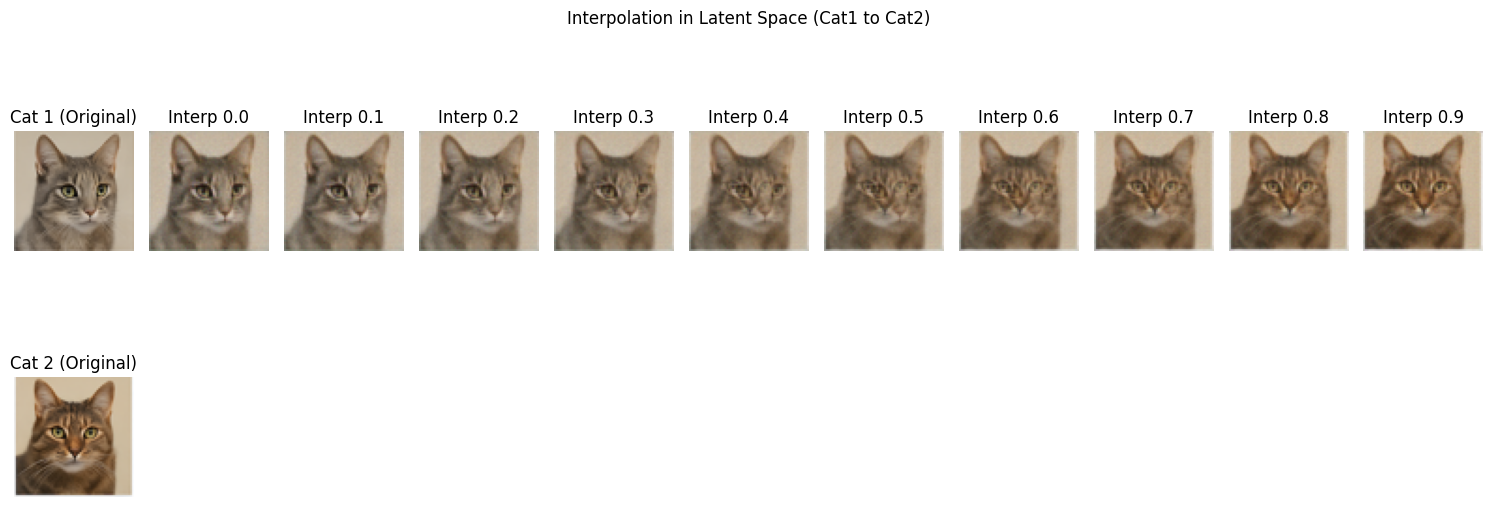

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import torchvision.transforms as T

# Ensure load_transform is defined if this cell is run independently
# If this cell is run after j8PeGm0mB5tc, load_transform is already defined.
if 'load_transform' not in locals():
    load_transform = T.Compose([
        T.Resize((64, 64)),
        T.ToTensor()
    ])

# Ensure dataset is defined if this cell is run independently
# If this cell is run after j8PeGm0mB5tc, dataset is already defined.
if 'dataset' not in locals() or len(dataset) < 2:
    print("Dataset not properly loaded or contains less than 2 images. Please run previous VAE cell first.")
    # Fallback or error handling if dataset isn't ready
    # For now, let's assume it's run after the VAE training cell.
    # You might want to add more robust error handling.
    exit()

# Ensure model, device, mu1, mu2 are defined
# These should be available from the previous VAE cell execution

# Load original images for display
original_cat1_img = Image.open(dataset.image_paths[0]).convert('RGB')
original_cat2_img = Image.open(dataset.image_paths[1]).convert('RGB')

# Resize for display consistency if needed (VAE uses 64x64)
original_cat1_img_resized = original_cat1_img.resize((64, 64))
original_cat2_img_resized = original_cat2_img.resize((64, 64))

# Interpolate in latent space
num_steps = 10
interpolated_images = []

with torch.no_grad():
    for i in range(num_steps + 1):
        alpha = i / num_steps
        # Interpolate between mu1 and mu2
        interpolated_latent = (1 - alpha) * torch.tensor(mu1).to(device) + alpha * torch.tensor(mu2).to(device)
        interpolated_latent = interpolated_latent.unsqueeze(0) # Add batch dimension

        # Decode the interpolated latent vector to an image
        decoded_img = model.decoder(interpolated_latent).squeeze(0).cpu()
        interpolated_images.append(decoded_img)

# Visualize original and interpolated images
plt.figure(figsize=(15, 6))

# Display Cat1 original image
plt.subplot(2, num_steps + 1, 1)
plt.imshow(original_cat1_img_resized)
plt.title("Cat 1 (Original)")
plt.axis('off')

# Display interpolated images
for i, img_tensor in enumerate(interpolated_images):
    plt.subplot(2, num_steps + 1, i + 2)
    plt.imshow(np.transpose(img_tensor.numpy(), (1, 2, 0)))
    plt.title(f"Interp {i/num_steps:.1f}")
    plt.axis('off')

# Display Cat2 original image
plt.subplot(2, num_steps + 1, num_steps + 2)
plt.imshow(original_cat2_img_resized)
plt.title("Cat 2 (Original)")
plt.axis('off')

plt.suptitle("Interpolation in Latent Space (Cat1 to Cat2)")
plt.tight_layout()
plt.show()

#โค้ด 8.5 Convolutional Autoencoder

#ใช้ภาพตัวเองภาพเดียว

Epoch 1/300 | Loss: 0.030495
Epoch 50/300 | Loss: 0.012168
Epoch 100/300 | Loss: 0.004299
Epoch 150/300 | Loss: 0.003285
Epoch 200/300 | Loss: 0.002702
Epoch 250/300 | Loss: 0.002548
Epoch 300/300 | Loss: 0.002181


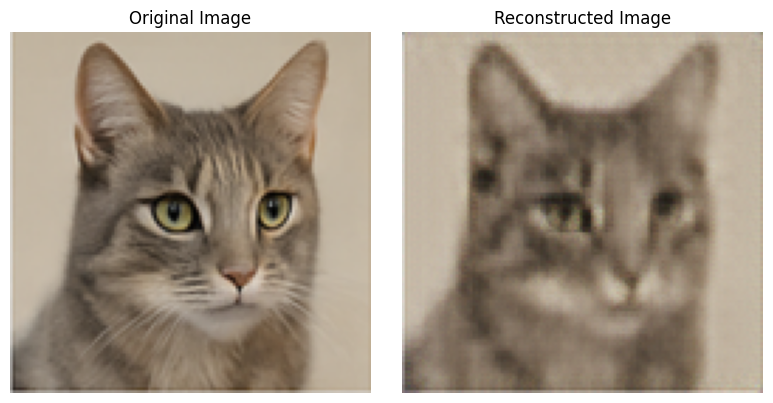

In [ ]:
# =========================
# Convolutional Autoencoder (Single Image)
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T

# -------------------------
# 0) Config
# -------------------------
IMAGE_PATH = "/content/drive/MyDrive/aiforeveryone/cnn/cats/cat1.jpg"   # 🔴 แก้เป็น path ภาพของคุณ
IMAGE_SIZE = 128
EPOCHS = 300
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -------------------------
# 1) Load Image
# -------------------------
img = Image.open(IMAGE_PATH).convert("RGB")

transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),   # [0,1]
])

x = transform(img).unsqueeze(0).to(DEVICE)   # (1,3,H,W)

# -------------------------
# 2) Convolutional Autoencoder
# -------------------------
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),  # 128 -> 64
            nn.ReLU(True),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 64 -> 32
            nn.ReLU(True),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),# 32 -> 16
            nn.ReLU(True),
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), # 16 -> 32
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),  # 32 -> 64
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),   # 64 -> 128
            nn.Sigmoid(),  # output [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = ConvAutoencoder().to(DEVICE)

# -------------------------
# 3) Loss & Optimizer
# -------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# -------------------------
# 4) Train (Overfit 1 Image)
# -------------------------
model.train()
for epoch in range(1, EPOCHS + 1):
    recon = model(x)
    loss = criterion(recon, x)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS} | Loss: {loss.item():.6f}")

# -------------------------
# 5) Reconstruct & Visualize
# -------------------------
model.eval()
with torch.no_grad():
    recon = model(x).cpu().squeeze()

orig = x.cpu().squeeze()

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(np.transpose(orig.numpy(), (1,2,0)))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Reconstructed Image")
plt.imshow(np.transpose(recon.numpy(), (1,2,0)))
plt.axis("off")

plt.tight_layout()
plt.show()


ใช้หลายภาพจาก Data set CIFAR-10
CIFAR-10 คือชุดข้อมูลมาตรฐานด้าน Computer Vision ที่ใช้กันแพร่หลายสำหรับสอนและทดสอบโมเดลเรียนรู้ของเครื่อง โดยเฉพาะงาน Image Classification และมักใช้เป็น dataset เริ่มต้น ในงานวิจัยและการเรียนการสอน

Device: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


Train cat images: 5000
Test cat images : 1000
Epoch 01/10 | train_loss=0.04688 | test_loss=0.02639
Epoch 02/10 | train_loss=0.02069 | test_loss=0.01592
Epoch 03/10 | train_loss=0.01446 | test_loss=0.01277
Epoch 04/10 | train_loss=0.01249 | test_loss=0.01192
Epoch 05/10 | train_loss=0.01079 | test_loss=0.01049
Epoch 06/10 | train_loss=0.00992 | test_loss=0.01770
Epoch 07/10 | train_loss=0.01082 | test_loss=0.00913
Epoch 08/10 | train_loss=0.00845 | test_loss=0.00812
Epoch 09/10 | train_loss=0.00779 | test_loss=0.00746
Epoch 10/10 | train_loss=0.00734 | test_loss=0.00723


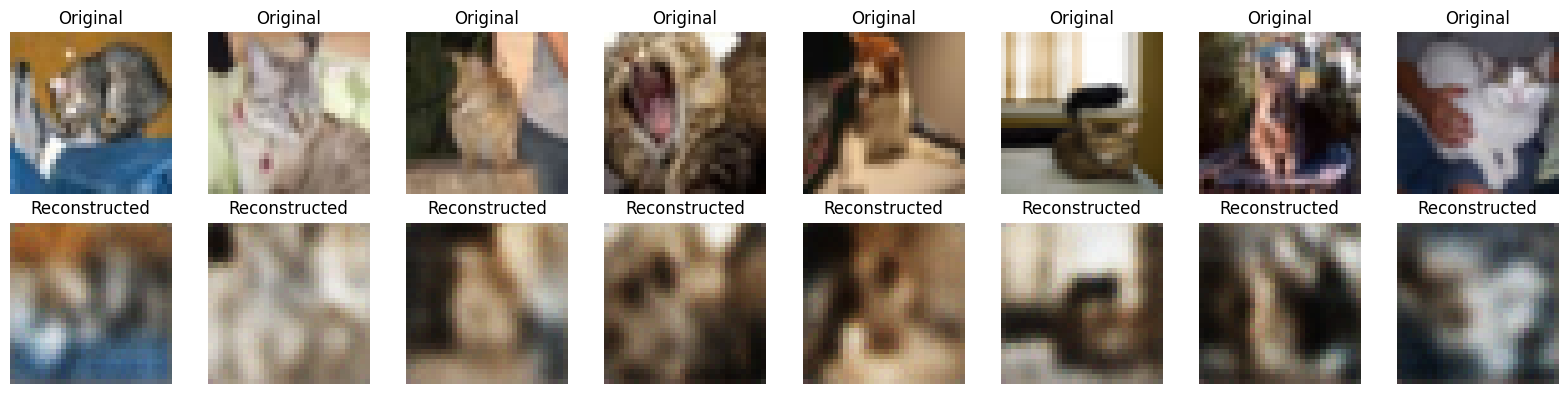

In [ ]:
# =========================
# Convolutional Autoencoder (CAE) - Cats (CIFAR-10) | Single Script
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

# -------------------------
# 0) Config
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 128
EPOCHS = 10
LR = 1e-3
IMAGE_SIZE = 32   # CIFAR-10 is 32x32

print("Device:", DEVICE)

# -------------------------
# 1) Dataset: CIFAR-10 -> only "cat"
# CIFAR-10 label mapping: 3 = cat
# -------------------------
transform = T.Compose([
    T.ToTensor(),  # [0,1]
])

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

CAT_LABEL = 3
train_indices = [i for i, (_, y) in enumerate(train_set) if y == CAT_LABEL]
test_indices  = [i for i, (_, y) in enumerate(test_set)  if y == CAT_LABEL]

train_cat = Subset(train_set, train_indices)
test_cat  = Subset(test_set, test_indices)

train_loader = DataLoader(train_cat, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_cat,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train cat images:", len(train_cat))
print("Test cat images :", len(test_cat))

# -------------------------
# 2) Convolutional Autoencoder
# -------------------------
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: (B,3,32,32) -> (B,128,4,4)
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 16x16 -> 8x8
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 8x8 -> 4x4
            nn.ReLU(True),
        )
        # Decoder: (B,128,4,4) -> (B,3,32,32)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 4x4 -> 8x8
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),   # 16x16 -> 32x32
            nn.Sigmoid(),  # output in [0,1]
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        return out

model = ConvAutoencoder().to(DEVICE)

# Loss/Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# -------------------------
# 3) Train
# -------------------------
def train_one_epoch(epoch):
    model.train()
    running = 0.0
    for x, _ in train_loader:
        x = x.to(DEVICE, non_blocking=True)

        recon = model(x)
        loss = criterion(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running += loss.item() * x.size(0)

    return running / len(train_loader.dataset)

@torch.no_grad()
def eval_loss():
    model.eval()
    running = 0.0
    for x, _ in test_loader:
        x = x.to(DEVICE, non_blocking=True)
        recon = model(x)
        loss = criterion(recon, x)
        running += loss.item() * x.size(0)
    return running / len(test_loader.dataset)

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(epoch)
    te = eval_loss()
    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={tr:.5f} | test_loss={te:.5f}")

# -------------------------
# 4) Visualize: Original vs Reconstructed
# -------------------------
@torch.no_grad()
def show_recon(num_images=8):
    model.eval()
    x, _ = next(iter(test_loader))
    x = x[:num_images].to(DEVICE)
    recon = model(x).cpu()

    x = x.cpu()
    # Plot
    plt.figure(figsize=(2*num_images, 4))
    for i in range(num_images):
        # Original
        plt.subplot(2, num_images, i+1)
        plt.imshow(np.transpose(x[i].numpy(), (1,2,0)))
        plt.title("Original")
        plt.axis("off")

        # Reconstructed
        plt.subplot(2, num_images, num_images+i+1)
        plt.imshow(np.transpose(recon[i].numpy(), (1,2,0)))
        plt.title("Reconstructed")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_recon(num_images=8)


# โค้ด 8.8 GAN
## GAN แบบ Fully connected ยังไม่ใช้ CNN

In [ ]:
!pip install torch torchvision matplotlib

2️⃣ เตรียม Dataset และ DataLoader

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import glob
from PIL import Image

# -------------------------------
# Custom Dataset for a single folder of images
# This bypasses the need for class subdirectories if all images are in one folder
# -------------------------------
class SingleFolderDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        # Define supported image extensions
        extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.ppm', '*.pgm', '*.tif', '*.tiff', '*.webp']
        for ext in extensions:
            self.image_paths.extend(glob.glob(os.path.join(root_dir, ext)))
        # Filter out any non-image files or directories that might be caught by glob (e.g. .ipynb_checkpoints)
        self.image_paths = [p for p in self.image_paths if os.path.isfile(p)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # Return a dummy label for autoencoder/GAN, as it's not classification
        return image, 0

image_size = 64
batch_size = 64

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Use the custom SingleFolderDataset instead of ImageFolder
dataset = SingleFolderDataset(
    root_dir="/content/drive/MyDrive/aiforeveryone/cnn/cats/",
    transform=transform
)

# Check if the dataset is empty after filtering
if len(dataset) == 0:
    raise FileNotFoundError("No valid image files found in '/content/drive/MyDrive/aiforeveryone/cnn/cats/'.\nPlease ensure your cat images (e.g., .jpg, .png) are directly within this folder.")

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
#หมายเหตุ
#Normalize(0.5, 0.5) ทำให้ค่า pixel อยู่ช่วง [-1, 1] (เหมาะกับ GAN)


3. สร้่าง Generator

In [ ]:
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, 3 * 64 * 64),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(-1, 3, 64, 64)

4. สร้าง Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3 * 64 * 64, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        img = img.view(img.size(0), -1)
        return self.model(img)


5. กำหนด Loss และ Optimizer

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=0.0002)
optimizer_D = torch.optim.Adam(D.parameters(), lr=0.0002)


6️⃣ วงรอบฝึก GAN (หัวใจหลัก)

In [ ]:

epochs = 500
noise_dim = 100

for epoch in range(epochs):
    for real_imgs, _ in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # label
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        z = torch.randn(batch_size, noise_dim).to(device)
        fake_imgs = G(z)

        real_loss = criterion(D(real_imgs), real_labels)
        fake_loss = criterion(D(fake_imgs.detach()), fake_labels)

        d_loss = real_loss + fake_loss

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        g_loss = criterion(D(fake_imgs), real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}]  D Loss: {d_loss.item():.4f}  G Loss: {g_loss.item():.4f}")

Epoch [1/500]  D Loss: 0.0695  G Loss: 4.2106
Epoch [2/500]  D Loss: 0.0850  G Loss: 3.7596
Epoch [3/500]  D Loss: 0.0797  G Loss: 3.8094
Epoch [4/500]  D Loss: 0.0914  G Loss: 3.7232
Epoch [5/500]  D Loss: 0.0791  G Loss: 4.0220
Epoch [6/500]  D Loss: 0.1055  G Loss: 3.6416
Epoch [7/500]  D Loss: 0.1294  G Loss: 3.4472
Epoch [8/500]  D Loss: 0.0687  G Loss: 4.4116
Epoch [9/500]  D Loss: 0.1540  G Loss: 3.1284
Epoch [10/500]  D Loss: 0.1663  G Loss: 3.1538
Epoch [11/500]  D Loss: 0.1414  G Loss: 3.2641
Epoch [12/500]  D Loss: 0.1546  G Loss: 3.2597
Epoch [13/500]  D Loss: 0.1504  G Loss: 3.3731
Epoch [14/500]  D Loss: 0.1813  G Loss: 3.2177
Epoch [15/500]  D Loss: 0.1472  G Loss: 3.2106
Epoch [16/500]  D Loss: 0.1298  G Loss: 3.5640
Epoch [17/500]  D Loss: 0.1576  G Loss: 3.3530
Epoch [18/500]  D Loss: 0.1482  G Loss: 3.3356
Epoch [19/500]  D Loss: 0.2552  G Loss: 2.5711
Epoch [20/500]  D Loss: 0.1227  G Loss: 3.7148
Epoch [21/500]  D Loss: 0.1577  G Loss: 3.1767
Epoch [22/500]  D Loss


7️⃣ แสดงภาพแมวที่ Generator สร้าง


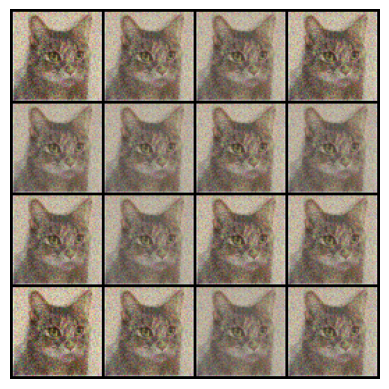

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

G.eval()
z = torch.randn(16, noise_dim).to(device)
fake_imgs = G(z).cpu()

grid = make_grid(fake_imgs, nrow=4, normalize=True)
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()


# โค้ด 8.9 Diffusions Model
โมเดลนี้ ไม่ได้สร้างภาพใหม่
แต่เรียนรู้ว่า noise ที่ควรถูกลบคืออะไร

Mounted at /content/drive
Epoch 0 | Loss: 1.0118
Epoch 300 | Loss: 0.1049
Epoch 600 | Loss: 0.3903
Epoch 900 | Loss: 0.0794
Epoch 1200 | Loss: 0.0723
Epoch 1500 | Loss: 0.0514
Epoch 1800 | Loss: 0.0543
Epoch 2100 | Loss: 0.0554
Epoch 2400 | Loss: 0.0463
Epoch 2700 | Loss: 0.0533


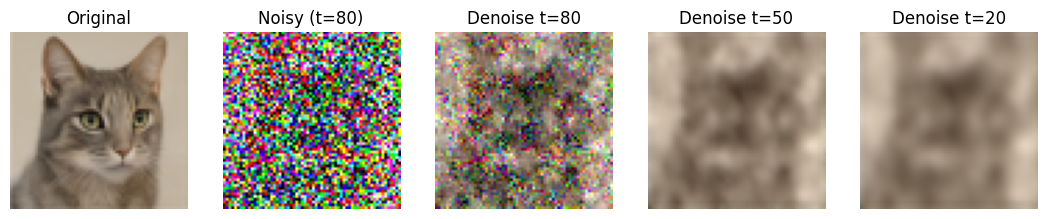

In [ ]:
# =========================================
# Simple Diffusion Model (Level 1)
# Show Forward + Reverse clearly
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import matplotlib.pyplot as plt
from PIL import Image

# ---------------------------
# 1) Mount Google Drive
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

IMAGE_PATH = '/content/drive/MyDrive/aiforeveryone/cnn/cats/cat1.jpg'

# ---------------------------
# 2) Load & preprocess image
# ---------------------------
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor()
])

img = Image.open(IMAGE_PATH).convert('RGB')
x0 = transform(img).unsqueeze(0)  # (1, 3, 64, 64)

# ---------------------------
# 3) Diffusion parameters
# ---------------------------
T_steps = 100
betas = torch.linspace(0.0001, 0.02, T_steps)
alphas = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

# ---------------------------
# 4) Simple CNN (Noise Predictor)
# ---------------------------
class SimpleDiffusionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1)
        )

    def forward(self, x):
        return self.net(x)

model = SimpleDiffusionNet()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# ---------------------------
# 5) Training (single image)
# ---------------------------
epochs = 3000

for epoch in range(epochs):
    t = torch.randint(0, T_steps, (1,))
    noise = torch.randn_like(x0)

    xt = torch.sqrt(alpha_bar[t]) * x0 + torch.sqrt(1 - alpha_bar[t]) * noise
    noise_pred = model(xt)

    loss = loss_fn(noise_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 300 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

# ---------------------------
# 6) Forward Diffusion (add noise & show)
# ---------------------------
t_start = 80
noise = torch.randn_like(x0)

x_noisy = (
    torch.sqrt(alpha_bar[t_start]) * x0 +
    torch.sqrt(1 - alpha_bar[t_start]) * noise
)

# ใช้ภาพ noisy นี้เป็นจุดเริ่ม reverse
x = x_noisy.clone()

# ---------------------------
# 7) Reverse Diffusion
# ---------------------------
steps_to_show = [80, 50, 20, 0]
results = []

for t in reversed(range(t_start)):
    with torch.no_grad():
        eps = model(x)
        x = (x - (1 - alphas[t]) / torch.sqrt(1 - alpha_bar[t]) * eps) \
            / torch.sqrt(alphas[t])

    if t in steps_to_show:
        results.append(x.clone())

# ---------------------------
# 8) Visualization
# ---------------------------
def show(img_tensor, title):
    img = img_tensor.squeeze().permute(1, 2, 0).clamp(0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

plt.figure(figsize=(16, 4))

plt.subplot(1, 6, 1)
show(x0, "Original")

plt.subplot(1, 6, 2)
show(x_noisy, f"Noisy (t={t_start})")

for i, r in enumerate(results):
    plt.subplot(1, 6, i + 3)
    show(r, f"Denoise t={steps_to_show[i]}")

plt.show()


โค้ดแสดงการเติม Noise

กรุณาอัปโหลดภาพ (เช่น .jpg / .png)


Saving IMG_0561.jpeg to IMG_0561 (2).jpeg
รูปที่ใช้เทรน มี shape: torch.Size([1, 3, 64, 64])
step 200/2000, loss = 0.087138
step 400/2000, loss = 0.046107
step 600/2000, loss = 0.039204
step 800/2000, loss = 0.055886
step 1000/2000, loss = 0.032015
step 1200/2000, loss = 0.039204
step 1400/2000, loss = 0.028002
step 1600/2000, loss = 0.025588
step 1800/2000, loss = 0.170568
step 2000/2000, loss = 0.047787
Training finished.
กำลัง sample ภาพใหม่จาก noise ...


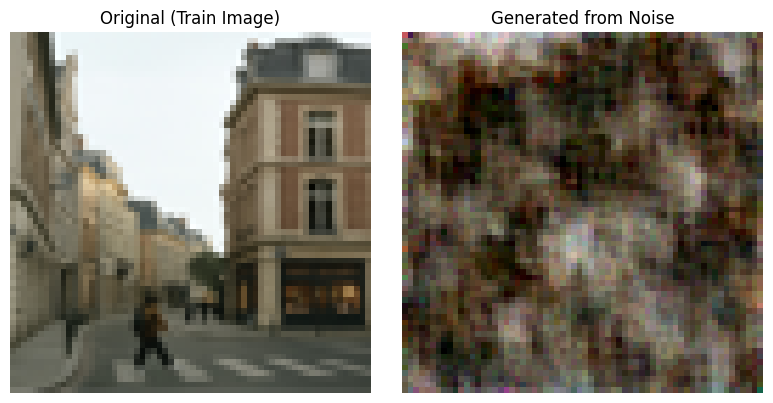

In [ ]:
# ============================================
# Simple DDPM-like Diffusion Model Demo (Single Image)
# - Run on Google Colab
# - Upload 1 image as training target
# - Train tiny diffusion model on that image
# - Sample new image from pure noise
# ============================================

# 1. (ถ้าใช้ Colab) ติดตั้ง PyTorch ถ้ายังไม่มี
# ถ้าเครื่องคุณติดตั้งแล้ว สามารถคอมเมนต์บรรทัดนี้ออกได้
#!pip install torch torchvision --quiet

from google.colab import files

import io
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# -----------------------------
# 2. อัปโหลดภาพ
# -----------------------------
print("กรุณาอัปโหลดภาพ (เช่น .jpg / .png)")
uploaded = files.upload()

filename = next(iter(uploaded.keys()))
img = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

# ปรับขนาดให้เล็กหน่อย เพื่อให้เทรนเร็วขึ้น
IMAGE_SIZE = 64
img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

# แปลงเป็น tensor ช่วง [0, 1]
img_np = np.array(img) / 255.0  # (H, W, C)
img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0).float()  # (1, 3, H, W)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_tensor = img_tensor.to(device)

print("รูปที่ใช้เทรน มี shape:", img_tensor.shape)

# -----------------------------
# 3. กำหนด Diffusion Hyperparameters
# -----------------------------
T = 200  # จำนวน time steps ของ diffusion (ลด/เพิ่มได้)
betas = torch.linspace(1e-4, 0.02, T).to(device)  # linear schedule

alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]], dim=0)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

def extract(a, t, x_shape):
    """
    ดึงค่า a[t] แล้ว reshape ให้อยู่ในรูป (B,1,1,1) เพื่อ broadcast กับ x
    a: tensor shape (T,)
    t: LongTensor shape (B,)
    """
    out = a.gather(-1, t)  # (B,)
    return out.view(-1, 1, 1, 1).expand(x_shape)

def q_sample(x_start, t, noise):
    """
    ส่ง x_0 + t + noise → ได้ x_t ตาม forward process:
    x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * noise
    """
    return (
        extract(sqrt_alphas_cumprod, t, x_start.shape) * x_start
        + extract(sqrt_one_minus_alphas_cumprod, t, x_start.shape) * noise
    )

# -----------------------------
# 4. นิยามโมเดลเล็ก ๆ (Tiny CNN + time as extra channel)
# -----------------------------
class TinyDiffusionModel(nn.Module):
    def __init__(self, img_channels=3, base_channels=64):
        super().__init__()
        # รับช่องภาพ + 1 ช่องสำหรับเวลา t
        self.conv1 = nn.Conv2d(img_channels + 1, base_channels, 3, padding=1)
        self.conv2 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv3 = nn.Conv2d(base_channels, base_channels, 3, padding=1)
        self.conv4 = nn.Conv2d(base_channels, img_channels, 3, padding=1)

    def forward(self, x, t):
        """
        x: (B, 3, H, W)
        t: (B,) time step
        """
        B, C, H, W = x.shape

        # แปลง t เป็นค่าในช่วง [0, 1] แล้วขยายให้เป็น map ขนาด H×W
        t_norm = t.float() / (T - 1)
        t_map = t_norm.view(B, 1, 1, 1).expand(B, 1, H, W)

        # concat เข้ากับช่องภาพ
        x_in = torch.cat([x, t_map], dim=1)  # (B, C+1, H, W)

        h = F.relu(self.conv1(x_in))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        out = self.conv4(h)  # ทำนาย noise epsilon_hat

        return out

model = TinyDiffusionModel().to(device)

# -----------------------------
# 5. เทรนโมเดลบนภาพเดียว (overfit) เพื่อสาธิตหลักการ
# -----------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
x0 = img_tensor  # (1, 3, H, W)

NUM_STEPS = 2000  # จำนวน step เทรน (น้อยๆ สำหรับ demo; เพิ่มได้ถ้าต้องการคุณภาพดีขึ้น)

for step in range(1, NUM_STEPS + 1):
    model.train()
    # สุ่ม time t (batch size = 1)
    t = torch.randint(0, T, (1,), device=device).long()

    # สุ่ม noise แล้วสร้าง x_t
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)

    # โมเดลพยายามทำนาย noise กลับมา
    pred_noise = model(x_t, t)
    loss = F.mse_loss(pred_noise, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 200 == 0:
        print(f"step {step}/{NUM_STEPS}, loss = {loss.item():.6f}")

print("Training finished.")

# -----------------------------
# 6. ฟังก์ชันสร้างภาพใหม่จาก noise (reverse process)
# -----------------------------
@torch.no_grad()
def p_sample(x, t):
    """
    1 step ของ reverse:
    x_t → x_{t-1}
    """
    betas_t = extract(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = extract(sqrt_recip_alphas, t, x.shape)

    # ทำนาย noise ด้วยโมเดล
    eps_theta = model(x, t)

    # mean ของ posterior q(x_{t-1} | x_t, x_0) ในรูปที่ใช้ eps-prediction
    model_mean = sqrt_recip_alphas_t * (x - betas_t * eps_theta / sqrt_one_minus_alphas_cumprod_t)

    if t[0] == 0:
        return model_mean
    else:
        posterior_var_t = extract(posterior_variance, t, x.shape)
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_var_t) * noise

@torch.no_grad()
def p_sample_loop(shape):
    """
    เริ่มจาก noise ล้วน แล้วไล่ t: T-1 → 0
    """
    x = torch.randn(shape, device=device)
    for i in reversed(range(T)):
        t = torch.full((shape[0],), i, device=device, dtype=torch.long)
        x = p_sample(x, t)
    return x

# -----------------------------
# 7. สร้างภาพใหม่จาก noise ล้วน
# -----------------------------
print("กำลัง sample ภาพใหม่จาก noise ...")
sampled = p_sample_loop(x0.shape)  # shape เดียวกับภาพต้นฉบับ

# -----------------------------
# 8. แสดงผลเปรียบเทียบ
# -----------------------------
def show_tensor_image(tensor, title=""):
    """
    tensor: (1, C, H, W) หรือ (C, H, W)
    """
    if tensor.dim() == 4:
        tensor = tensor[0]
    img = tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = np.clip(img, 0.0, 1.0)
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
show_tensor_image(x0, "Original (Train Image)")

plt.subplot(1,2,2)
show_tensor_image(sampled, "Generated from Noise")

plt.tight_layout()
plt.show()


# โค้ด 8.10 จำแนกเสียงสัตว์กับเสียงทั่วไป (ไม่ใช่สัตว์)
Dataset from https://github.com/karolpiczak/ESC-50?tab=readme-ov-file

In [ ]:
# 1: Import
import tensorflow as tf
import numpy as np
import os, zipfile
from tensorflow.keras import layers, models
# 2 กำหนดชุดข้อมูล
DATA_DIR = "/content/drive/MyDrive/aiforeveryone/cnn/audios/"
CLASS_NAMES = ["animals", "notanimals"]

for cls in CLASS_NAMES:
    print(cls, "files:", len(os.listdir(os.path.join(DATA_DIR, cls))))


print("Classes:", CLASS_NAMES)
#  3: ฟังก์ชันเสียง → Spectrogram
SAMPLE_RATE = 16000
DURATION = 1  # วินาที

def wav_to_spectrogram(path):
    audio = tf.io.read_file(path)
    wav, _ = tf.audio.decode_wav(audio, desired_channels=1)
    wav = tf.squeeze(wav)

    wav = wav[:SAMPLE_RATE * DURATION]
    wav = tf.pad(wav, [[0, SAMPLE_RATE * DURATION - tf.shape(wav)[0]]])

    stft = tf.signal.stft(wav, frame_length=256, frame_step=128)
    spec = tf.abs(stft)

    return spec[..., tf.newaxis]  # (time, freq, 1)
#4. โหลดข้อมูลจากโฟลเดอร์
paths = []
labels = []

for label, cls in enumerate(CLASS_NAMES):
    folder = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(folder):
        if fname.endswith(".wav"):
            paths.append(os.path.join(folder, fname))
            labels.append(label)

paths = tf.constant(paths)
labels = tf.constant(labels)

print("Total samples:", len(paths))
# 5: สร้าง Dataset + Split
def make_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, y: (wav_to_spectrogram(p), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.shuffle(100)
    ds = ds.batch(16).prefetch(tf.data.AUTOTUNE)
    return ds

# split 80 / 20
n = len(paths)
idx = tf.random.shuffle(tf.range(n))

train_idx = idx[:int(0.8*n)]
val_idx   = idx[int(0.8*n):]

train_ds = make_dataset(
    tf.gather(paths, train_idx),
    tf.gather(labels, train_idx)
)

val_ds = make_dataset(
    tf.gather(paths, val_idx),
    tf.gather(labels, val_idx)
)
# 6: CNN Model (เหมือนเดิม)
model = models.Sequential([
    layers.Input(shape=(None, None, 1)),

    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),
    layers.Dense(2, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
# 7: Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)
# 8: ทดสอบไฟล์จากโฟลเดอร์ (ไม่ต้อง upload)
TEST_FILE = "/content/drive/MyDrive/aiforeveryone/cnn/audios/test.wav"  # เปลี่ยนเป็น path ที่คุณมี

x = wav_to_spectrogram(TEST_FILE)
x = tf.expand_dims(x, 0)

pred = model.predict(x)
cls = CLASS_NAMES[np.argmax(pred)]

print("Prediction:", cls)
print("Probabilities:", pred)


animals files: 10
notanimals files: 10
Classes: ['animals', 'notanimals']
Total samples: 20


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, None, None, 16) │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, None, None, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, None, None, 32) │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, None, None, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,866 (19.01 KB)

 Trainable params: 4,866 (19.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.5000 - loss: 0.6962 - val_accuracy: 0.7500 - val_loss: 0.6603
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step - accuracy: 0.5625 - loss: 0.6913 - val_accuracy: 0.5000 - val_loss: 0.6654
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.5000 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6764
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.5000 - loss: 0.6860 - val_accuracy: 0.5000 - val_loss: 0.6897
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.5000 - loss: 0.6848 - val_accuracy: 0.5000 - val_loss: 0.7024
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5625 - loss: 0.6841 - val_accuracy: 0.5000 - val_loss: 0.7116
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.6250 - loss: 0.6834 - val_accuracy: 0.5000 - val_loss: 0.7163
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.6875 - loss: 0.6825 - val_accuracy: 0.5000 - val_

#โค้ด 8.11 วิเคราะห์บทกวีจำแนกว่าเศร้าหรือสดใส

In [ ]:
#1️⃣ เตรียมไลบรารี (Google Colab)
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import layers, models
import numpy as np
#2️⃣ ตัวอย่างข้อมูลบทกวี (ใช้ข้อความตัวอย่าง / เขียนเอง)
texts = [
    "Tears fall quietly in the lonely night",
    "The sun rises with hope and gentle light",
    "My heart is broken and dreams fade away",
    "Smiles bloom under the bright blue sky",
    "Silence surrounds me, sorrow deep inside",
    "Joy dances freely in the morning breeze"
]

# 0 = เศร้า, 1 = สดใส
labels = [0, 1, 0, 1, 0, 1]

labels = np.array(labels)
#3️⃣ แปลงข้อความเป็นตัวเลข (Tokenization)
vocab_size = 1000
max_len = 20

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences, maxlen=max_len, padding="post")

print("ตัวอย่าง sequence:", padded[0])
#4️⃣ สร้างโมเดล CNN (Conv1D)
model = models.Sequential([
    layers.Embedding(vocab_size, 64, input_length=max_len),

    layers.Conv1D(filters=64, kernel_size=3, activation="relu"),
    layers.GlobalMaxPooling1D(),

    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()
#Conv1D → ตรวจจับ pattern ของคำติดกัน
#kernel_size=3 → ดูคำทีละ 3 คำ (เหมือน phrase สั้น ๆ)
#5️⃣ เทรนโมเดล
history = model.fit(
    padded,
    labels,
    epochs=50,
    batch_size=2,
    verbose=1
)
#6️⃣ ทดลองทำนายบทกวีใหม่
def predict_poem(poem):
    seq = tokenizer.texts_to_sequences([poem])
    pad = pad_sequences(seq, maxlen=max_len, padding="post")
    prob = model.predict(pad)[0][0]

    emotion = "สดใส" if prob >= 0.5 else "เศร้า"
    return emotion, prob


test_poem = "The night is cold and my heart feels empty"
emotion, score = predict_poem(test_poem)

print("บทกวี:", test_poem)
print("อารมณ์:", emotion)
print("ความมั่นใจ:", score)

ตัวอย่าง sequence: [5 6 7 3 2 8 9 0 0 0 0 0 0 0 0 0 0 0 0 0]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 52ms/step - accuracy: 0.1458 - loss: 0.6997   
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7292 - loss: 0.6737
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 1.0000 - loss: 0.6385 
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.6131
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 1.0000 - loss: 0.5921
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 1.0000 - loss: 0.5779 
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.5653 
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.5299
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.5021
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.4802
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.4454
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 

# Video Motion

In [ ]:
import cv2
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

# -------------------------------
# 1) Config
# -------------------------------
VIDEO_PATH = "/content/drive/MyDrive/aiforeveryone/accident.mp4"   # 👈 ระบุไฟล์วิดีโอที่นี่
NUM_FRAMES = 16
IMG_SIZE = 224

# -------------------------------
# 2) Load video frames
# -------------------------------
def load_video(path, num_frames=16, size=224):
    cap = cv2.VideoCapture(path)
    frames = []

    # Check if the video file was opened successfully
    if not cap.isOpened():
        print(f"Error: Could not open video file at {path}. Returning empty tensor.")
        # Return a tensor of zeros with the expected final shape
        return torch.zeros(num_frames, 3, size, size, dtype=torch.float32)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Ensure step is at least 1 to avoid division by zero if total_frames is 0 or less than num_frames
    step = max(total_frames // num_frames, 1)

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or len(frames) >= num_frames:
            break

        if idx % step == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (size, size))
            frames.append(frame)
        idx += 1

    cap.release()

    # If no frames were successfully loaded, return a zero tensor
    if not frames:
        print(f"Warning: No frames could be loaded from {path}. Returning empty tensor.")
        return torch.zeros(num_frames, 3, size, size, dtype=torch.float32)

    # padding กรณีเฟรมไม่พอ
    while len(frames) < num_frames:
        frames.append(frames[-1])

    frames = np.array(frames) / 255.0
    frames = torch.tensor(frames, dtype=torch.float32)
    frames = frames.permute(0, 3, 1, 2)  # (T, C, H, W)

    return frames

# -------------------------------
# 3) CNN + LSTM Model
# -------------------------------
class CNN_LSTM(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        backbone = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=256,
            batch_first=True
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        f = self.cnn(x)                 # (B*T, 512, 1, 1)
        f = f.view(B, T, -1)            # (B, T, 512)

        lstm_out, _ = self.lstm(f)
        last_time = lstm_out[:, -1, :]  # timestep สุดท้าย

        return self.fc(last_time)

# -------------------------------
# 4) Load video file
# -------------------------------
video = load_video(VIDEO_PATH, NUM_FRAMES, IMG_SIZE)
video = video.unsqueeze(0)  # (1, T, C, H, W)

print("📦 Video tensor shape:", video.shape)

# -------------------------------
# 5) Run model
# -------------------------------
model = CNN_LSTM(num_classes=2)
output = model(video)

pred_class = torch.argmax(output, dim=1)

print("🧠 Logits:", output.detach().numpy())
print("🎯 Predicted class:", int(pred_class))

Error: Could not open video file at /content/drive/MyDrive/aiforeveryone/accident.mp4. Returning empty tensor.
📦 Video tensor shape: torch.Size([1, 16, 3, 224, 224])


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


🧠 Logits: [[0.24281956 0.06610865]]
🎯 Predicted class: 0


# โค้ด สกัดฟีเจอร์จากภาพเลข

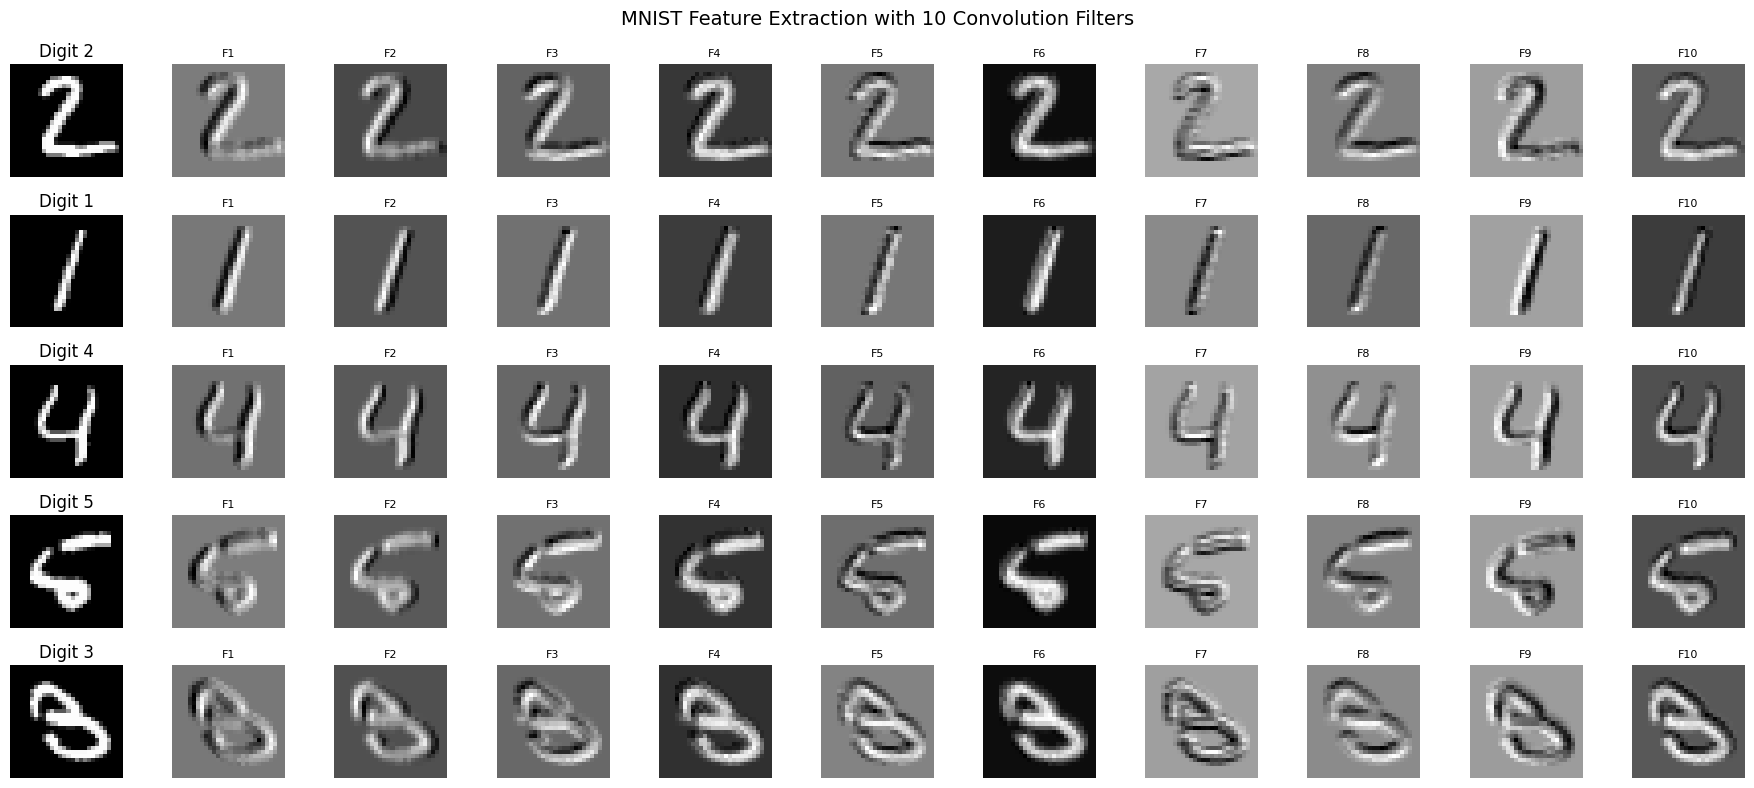

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load MNIST
# -----------------------------
transform = transforms.ToTensor()

mnist = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# เลือกตัวเลข 1–5 อย่างละ 1 ภาพ
selected = []
used_labels = set()

for img, label in mnist:
    if label in [1, 2, 3, 4, 5] and label not in used_labels:
        selected.append((img, label))
        used_labels.add(label)
    if len(selected) == 5:
        break

# -----------------------------
# 2) CNN with 10 filters
# -----------------------------
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=10,  # 👈 10 ฟิลเตอร์
            kernel_size=3,
            padding=1
        )

    def forward(self, x):
        return self.conv(x)

model = SimpleCNN()

# -----------------------------
# 3) Extract and visualize features
# -----------------------------
fig, axes = plt.subplots(
    nrows=5, ncols=11, figsize=(18, 8)
)

for row, (img, label) in enumerate(selected):
    img = img.unsqueeze(0)        # (1, 1, 28, 28)
    features = model(img)         # (1, 10, 28, 28)

    # ภาพต้นฉบับ
    axes[row, 0].imshow(img[0, 0], cmap="gray")
    axes[row, 0].set_title(f"Digit {label}")
    axes[row, 0].axis("off")

    # Feature maps จาก 10 ฟิลเตอร์
    for f in range(10):
        axes[row, f + 1].imshow(
            features[0, f].detach().numpy(),
            cmap="gray"
        )
        axes[row, f + 1].set_title(f"F{f+1}", fontsize=8)
        axes[row, f + 1].axis("off")

plt.suptitle("MNIST Feature Extraction with 10 Convolution Filters", fontsize=14)
plt.tight_layout()
plt.show()


#โค้ดสำหรับเทรนจำแนกตัวเลขและทดสอบด้วยภาพนำเข้า

In [ ]:
# =========================================
# CNN Feature Extraction (10 filters)
# Train on MNIST digits 1–5
# Test with image file path
# =========================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from PIL import Image
import numpy as np

# -----------------------------
# 1) Config
# -----------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 5
BATCH_SIZE = 64
LR = 0.001

# -----------------------------
# 2) MNIST (เฉพาะเลข 1–5)
# -----------------------------
transform = transforms.ToTensor()

train_full = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_full = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

def filter_1_to_5(dataset):
    imgs, labels = [], []
    for img, label in dataset:
        if 1 <= label <= 5:
            imgs.append(img)
            labels.append(label - 1)  # แปลง label: 1–5 → 0–4
    return torch.stack(imgs), torch.tensor(labels)

X_train, y_train = filter_1_to_5(train_full)
X_test, y_test   = filter_1_to_5(test_full)

train_loader = torch.utils.data.DataLoader(
    list(zip(X_train, y_train)),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# -----------------------------
# 3) CNN Feature Extractor + Classifier
# -----------------------------
class CNN_Feature_Classifier(nn.Module):
    def __init__(self):
        super().__init__()

        # 🔹 Feature Extractor
        self.conv = nn.Conv2d(
            in_channels=1,
            out_channels=10,   # 👈 10 ฟิลเตอร์
            kernel_size=3,
            padding=1
        )

        # 🔹 Classifier
        self.fc = nn.Linear(10 * 28 * 28, 5)  # 5 classes (1–5)

    def forward(self, x):
        features = self.conv(x)           # (B, 10, 28, 28)
        flat = features.view(x.size(0), -1)
        out = self.fc(flat)
        return out, features

model = CNN_Feature_Classifier().to(DEVICE)

# -----------------------------
# 4) Train
# -----------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    total_loss = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        logits, _ = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {total_loss:.4f}")

# -----------------------------
# 5) Test with image file
# -----------------------------
def predict_image(image_path):
    model.eval()

    img = Image.open(image_path).convert("L")
    img = img.resize((28, 28))
    img = transforms.ToTensor()(img)
    img = img.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits, features = model(img)
        pred = torch.argmax(logits, dim=1).item()

    print("Predicted digit:", pred + 1)  # แปลงกลับ 0–4 → 1–5
    print("Feature shape:", features.shape)

# -----------------------------
# 6) Example usage
# -----------------------------
# ใส่พาธภาพตัวเลข 1–5 ที่คุณมี
predict_image("test_digit.png")
